## Week 6 Assignment: Analyzing and Visualizing Correlations Assignment

### Purpose
Calculate correlations between variables, test their significance, and visualize the relationships. Use a subsample from the General Social Survey for this assignment. The subsample is an Excel file that will need to be imported into R.
The Excel file can be downloaded here: gss data.xlsx
The Excel file is also available in the R Resources folder.

### Steps:
    1. Calculate correlations for the variables hrsonline and hrsworked. These variables measure the hours worked and hours spent online in the previous week.
        - Calculate Pearson's correlation coefficient
        - Calculate Spearman's correlation coefficient
        - Calculate Kendall's correlation coefficient
    
    2. Test Correlation Significance
    Perform a correlation significance test for the correlation coefficients calculated above.
    3. Visualize Relationship
    Create a scatterplot with a linear trend line for the variables hrsonline and hrsworked.
    
    4. Calculate the point bi-serial correlation
    Calculate the point bi-serial correlation between years of education and being married, and test if the correlation is statistically significant.
    
    5. Calculate partial correlation
    Calculate the partial correlation between hours online and hours worked, while controlling for age, and test if the correlation is statistically significant.



In [37]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
import pingouin as pg
from pathlib import Path

from statsmodels.graphics.gofplots import qqplot

In [38]:
#1. load the festival dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "gss data.xlsx"

# verify the path
# print(fname)

df = pd.read_excel(fname)
df.head()
df.describe()

# df[["hrsonline", "hrsworked"]].isna().sum() # no missing data


,id,hrsworked,childs,age,educ,hrsonline,liberal,overtime,married
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,1361.653061,41.622449,1.357143,40.204082,14.826531,5.765306,0.275510,0.387755,0.530612
std,805.223669,14.795872,1.348921,11.768348,2.773310,7.177860,0.449068,0.489743,0.501628
min,43.000000,2.000000,0.000000,20.000000,8.000000,0.000000,0.000000,0.000000,0.000000
25%,616.000000,37.750000,0.000000,30.000000,12.000000,1.000000,0.000000,0.000000,0.000000
50%,1344.000000,40.000000,1.000000,41.000000,14.000000,3.000000,0.000000,0.000000,1.000000
75%,2078.750000,49.500000,2.000000,49.000000,17.000000,7.000000,1.000000,1.000000,1.000000
max,2700.000000,89.000000,7.000000,69.000000,20.000000,35.000000,1.000000,1.000000,1.000000


slope: 0.282
y-intercept: 39.994
r: 0.137
p: 0.179
se: 0.208
LinregressResult(slope=np.float64(0.282398701418027), intercept=np.float64(39.99433401733484), rvalue=np.float64(0.13699890147010924), pvalue=np.float64(0.17857007000651717), stderr=np.float64(0.20839902887521597), intercept_stderr=np.float64(1.9126750459422508))


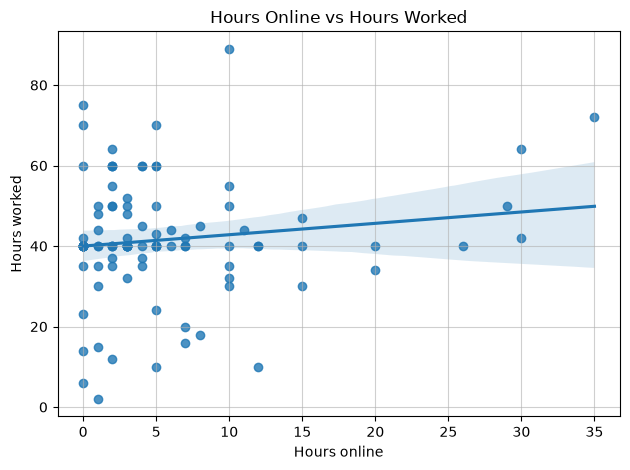

In [ ]:

fig, ax = plt.subplots()

sns.regplot(data=df, x="hrsonline", y="hrsworked", ax=ax)
ax.grid(True, alpha=0.6)
ax.set_title("Hours Online vs Hours Worked")
ax.set_xlabel("Hours online")
ax.set_ylabel("Hours worked")
plt.tight_layout()

slope, intercept, r, p, se = stats.linregress(df["hrsonline"], df["hrsworked"])
print(f"slope: {slope:.3f}")
print(f"y-intercept: {intercept:.3f}")
print(f"r: {r:.3f}")
print(f"p: {p:.3f}")
print(f"se: {se:.3f}")

# res = stats.linregress(df["hrsonline"], df["hrsworked"])
# print(res)

In [40]:
# correlations calculations 
# covariance matrix
# cov = df[["hrsonline", "hrsworked"]].cov()
# print(cov)

pearson = stats.pearsonr(x=df["hrsonline"], y=df["hrsworked"])
print(f"Pearson: r = {pearson.statistic:.3f}, p = {pearson.pvalue:.4f}")

spearman = stats.spearmanr(a=df["hrsonline"], b=df["hrsworked"])
print(f"Spearman: r = {spearman.statistic:.3f}, p = {spearman.pvalue:.4f}")

kendall = stats.kendalltau(x=df["hrsonline"], y=df["hrsworked"])
print(f"Kendall: r = {kendall.statistic:.3f}, p = {kendall.pvalue:.4f}")

print(f"The coefficient of determination Pearson R-squared: {pearson.statistic ** 2:.4f}")

summary = pd.DataFrame({
    "Method": ["Pearson", "Spearman", "Kendall"],
    "Correlation": [
        pearson.statistic,
        spearman.statistic,
        kendall.statistic
    ],
    "p-value": [
        pearson.pvalue,
        spearman.pvalue,
        kendall.pvalue
    ]
}).style.format({
    "Correlation": "{:.3f}",
    "p-value": "{:.4f}"
})

summary



Pearson: r = 0.137, p = 0.1786
Spearman: r = 0.055, p = 0.5909
Kendall: r = 0.041, p = 0.5882
The coefficient of determination Pearson R-squared: 0.0188


,Method,Correlation,p-value
0,Pearson,0.137,0.1786
1,Spearman,0.055,0.5909
2,Kendall,0.041,0.5882


In [41]:
# out of the scope
print("additional stats done in R out of the box by the cor.test():\n")
n = len(df[["hrsonline", "hrsworked"]].dropna())
t = pearson.statistic * np.sqrt((n - 2) / (1 - r**2))
df_t = n - 2

print("r =", pearson.statistic)
print("t =", t) # test statistic
print("df =", df_t) # degrees of freedom
print("p =", p)
print("95% CI =", pearson.confidence_interval())

additional stats done in R out of the box by the cor.test():

r = 0.13699890147010926
t = 1.355086455739293
df = 96
p = 0.17857007000651717
95% CI = ConfidenceInterval(low=np.float64(-0.06313818022142798), high=np.float64(0.32654311007544734))


The results indicate a weak positive relationship between hours online and hours worked.  
The values of the correlation coefficients are small though and none of the correlations is statistically significant since all p-values are greater than 0.05.  
Coefficient of determination R2 = 0.0188 or 1.88% suggests that the linear relationship represented by Pearson’s correlation accounts for 1.88% only of the variations in hours worked

note:  
1. **H₀:** population correlation $\rho = 0$
2. **H₁:** population correlation $\rho \neq 0$

the 0 falls inside the 95% CI, so we fail to reject the null hypothesis


In [42]:
# out of scope of the assignment:
# def boot(data: pd.DataFrame, count):
#     bootstrap_taus=[]
#     for _ in range(count):
#         bootstrap_sample = df.sample(n=len(df), replace=True)
#         tau_kendall, p_kendall = stats.kendalltau(x=bootstrap_sample["hrsonline"], y=bootstrap_sample["hrsworked"])
#         bootstrap_taus.append(tau_kendall)
#     return bootstrap_taus
    
# # tau_kendall, p_kendall = stats.kendalltau(x=df["hrsonline"], y=df["hrsworked"])

# # resampling
# taus = boot(df, 2000)

# bootstrap_se = np.std(taus, ddof=1)




### Point bi-serial correlation

In [43]:
print(df["married"].value_counts())
point_biserial = stats.pointbiserialr(x=df["married"], y=df["educ"])
print(f"Point bi-serial: r = {point_biserial.statistic:.3f}, p = {point_biserial.pvalue:.4f}")


df.groupby("married")["educ"].agg(["count", "mean", "std", "median"])

married
1    52
0    46
Name: count, dtype: int64
Point bi-serial: r = -0.185, p = 0.0680


,count,mean,std,median
married,,,,
0,46,15.369565,2.610736,15.5
1,52,14.346154,2.848354,13.0


0 is unmarried, while 1 is married  
married has lower mean of years of education which conceptually explains the negative correlation value -0.185, yet it's p > 0.05 which is statistically insignificant, i.e not providing significant evidence agains the null hypothesis (no correlation)

### Partial correlation

Partial correlation measures the relationship between two variables while controlling for the effects of one or more other variables on both variables.


In [53]:
cor_data = df[["hrsonline", "hrsworked", "age"]].dropna()

# hrsonline = slope * age + yIntercept
hrsonline_model = stats.linregress(x=cor_data["age"], y=cor_data["hrsonline"])

# hrsworked = slope * age + yIntercepts
hrsworked_model = stats.linregress(x=cor_data["age"], y=cor_data["hrsworked"])

cor_data["hrsonline_predicted"] = (hrsonline_model.slope * cor_data["age"] + hrsonline_model.intercept)

cor_data["hrsworked_predicted"] = (hrsworked_model.slope * cor_data["age"] + hrsworked_model.intercept)

# residual = actual - predicted by the linear equation from the fitted line
# residual means part of hours worked/online that are not explained by age
cor_data["hrsonline_residual"] = (cor_data["hrsonline"] - cor_data["hrsonline_predicted"])
cor_data["hrsworked_residual"] = (cor_data["hrsworked"] - cor_data["hrsworked_predicted"])

display(cor_data.head())
display(cor_data.describe())

# correlate the residuals
r_partial, p_partial = stats.pearsonr(x=cor_data["hrsonline_residual"], y=cor_data["hrsworked_residual"])
print(f"\nPartial correlation: r = {r_partial:.3f}, p = {p_partial:.4f}")


,hrsonline,hrsworked,age,hrsonline_predicted,hrsworked_predicted,hrsonline_residual,hrsworked_residual
0,3,40,42,5.742405,41.398867,-2.742405,-1.398867
1,5,10,52,5.614887,40.153922,-0.614887,-30.153922
2,5,43,52,5.614887,40.153922,-0.614887,2.846078
3,5,70,23,5.984688,43.764263,-0.984688,26.235737
4,1,2,59,5.525625,39.282460,-4.525625,-37.282460


,hrsonline,hrsworked,age,hrsonline_predicted,hrsworked_predicted,hrsonline_residual,hrsworked_residual
count,98.000000,98.000000,98.000000,98.000000,98.000000,9.800000e+01,9.800000e+01
mean,5.765306,41.622449,40.204082,5.765306,41.622449,-5.437827e-16,-3.915235e-15
std,7.177860,14.795872,11.768348,0.150067,1.465095,7.176291e+00,1.472316e+01
min,0.000000,2.000000,20.000000,5.398107,38.037515,-6.010192e+00,-3.728246e+01
25%,1.000000,37.750000,30.000000,5.653143,40.527406,-4.554317e+00,-4.209092e+00
50%,3.000000,40.000000,41.000000,5.755157,41.523362,-2.665894e+00,-1.274373e+00
75%,7.000000,49.500000,49.000000,5.895426,42.892801,1.279911e+00,7.200570e+00
max,35.000000,89.000000,69.000000,6.022944,44.137746,2.907907e+01,4.884608e+01



Partial correlation: r = 0.136, p = 0.1830
